# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


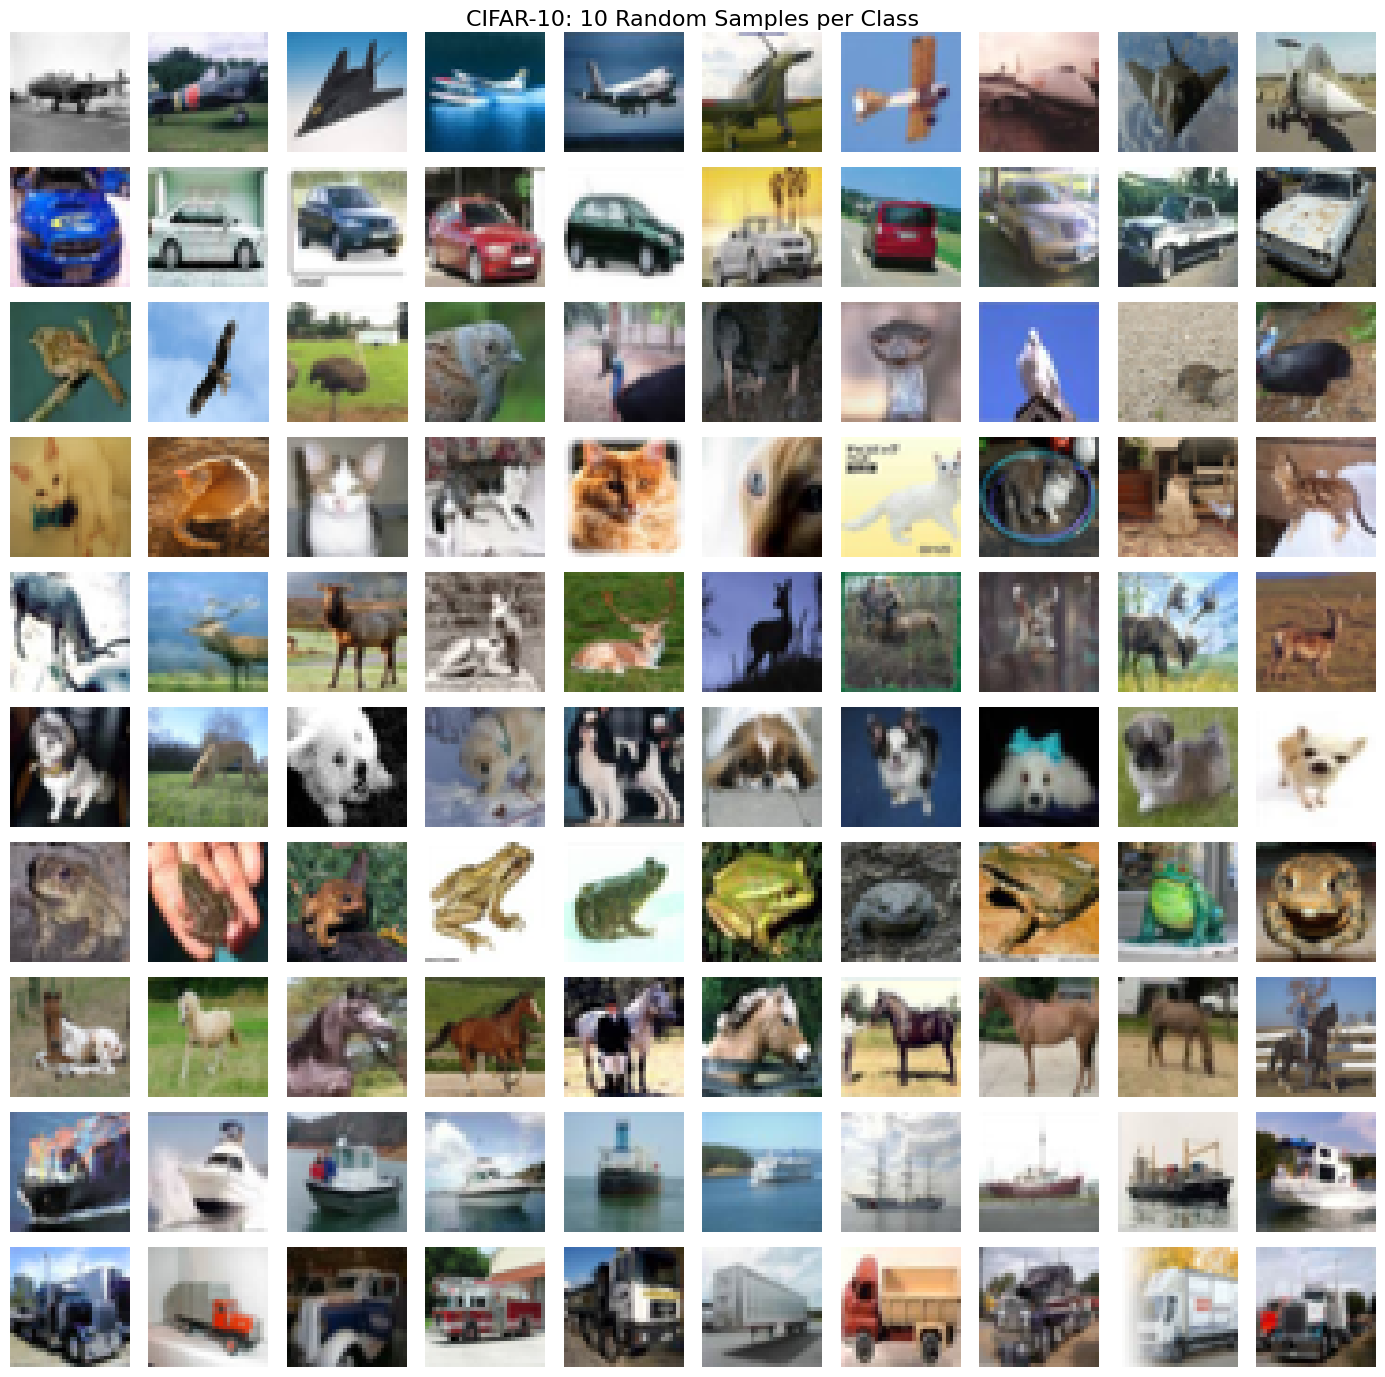

x_train: (50000, 32, 32, 3)
y_train: (50000, 10)
x_test : (10000, 32, 32, 3)
y_test : (10000, 10)


In [2]:
# Reproducibility
np.random.seed(42)

# Visualize 10 random images from each of the 10 CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(10, 10, figsize=(14, 14))
for class_id in range(10):
    indices = np.where(y_train.flatten() == class_id)[0]
    selected = np.random.choice(indices, 10, replace=False)
    for col, idx in enumerate(selected):
        axes[class_id, col].imshow(x_train[idx])
        axes[class_id, col].axis('off')
        if col == 0:
            axes[class_id, col].set_ylabel(class_names[class_id], fontsize=9)
plt.suptitle('CIFAR-10: 10 Random Samples per Class', fontsize=16)
plt.tight_layout()
plt.show()

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test :', x_test.shape)
print('y_test :', y_test.shape)

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [3]:
from keras.backend import clear_session
clear_session()

In [4]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [5]:
model1.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history1 = model1.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=512,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.2032 - loss: 2.2308 - val_accuracy: 0.2663 - val_loss: 2.1549
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2815 - loss: 2.0813 - val_accuracy: 0.2787 - val_loss: 2.0275
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3117 - loss: 1.9735 - val_accuracy: 0.3299 - val_loss: 1.9359
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3344 - loss: 1.9075 - val_accuracy: 0.3436 - val_loss: 1.8907
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3480 - loss: 1.8690 - val_accuracy: 0.3613 - val_loss: 1.8443
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3621 - loss: 1.8304 - val_accuracy: 0.3635 - val_loss: 1.8240
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3739 - loss: 1.8010 - val_accuracy: 0.3541 - val_loss: 1.8199
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3807 - loss: 1.7833 - val_accuracy: 0.3798 - v

*   Plot the cross entropy loss curve and the accuracy curve

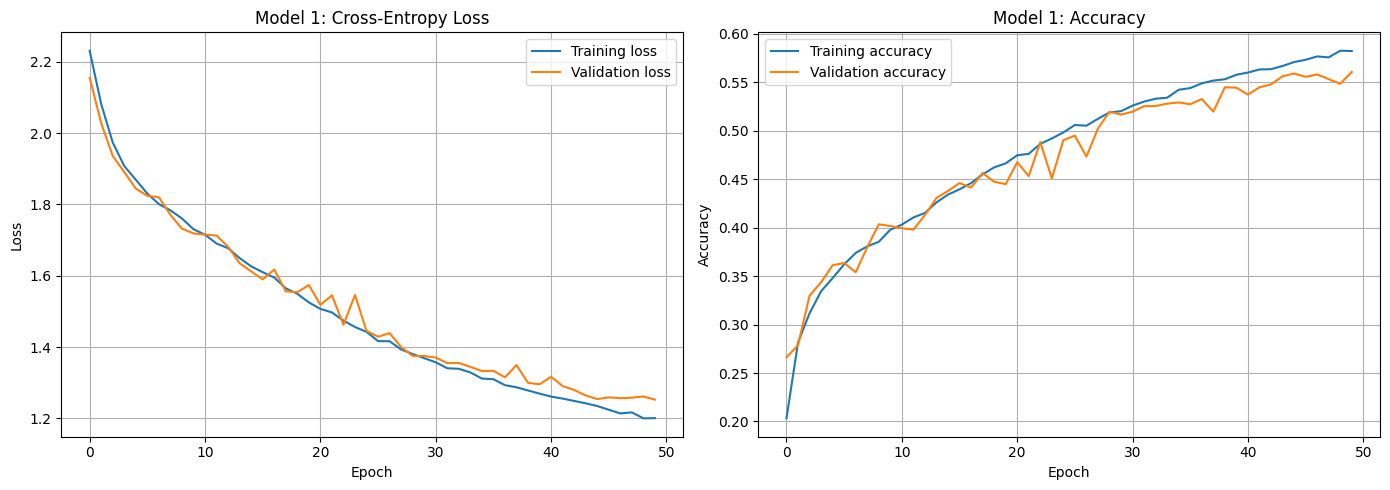

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['loss'], label='Training loss')
axes[0].plot(history1.history['val_loss'], label='Validation loss')
axes[0].set_title('Model 1: Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history1.history['accuracy'], label='Training accuracy')
axes[1].plot(history1.history['val_accuracy'], label='Validation accuracy')
axes[1].set_title('Model 1: Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [7]:
from keras.backend import clear_session
clear_session()

In [8]:
from tensorflow.keras.layers import Input

model2 = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [9]:
model2.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history2 = model2.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=512,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.2056 - loss: 2.2299 - val_accuracy: 0.2705 - val_loss: 2.1299
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.2710 - loss: 2.0615 - val_accuracy: 0.2874 - val_loss: 1.9983
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3091 - loss: 1.9618 - val_accuracy: 0.3410 - val_loss: 1.8979
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3430 - loss: 1.8863 - val_accuracy: 0.3437 - val_loss: 1.8628
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3580 - loss: 1.8338 - val_accuracy: 0.3721 - val_loss: 1.8016
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3738 - loss: 1.7951 - val_accuracy: 0.3836 - val_loss: 1.7609
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3853 - loss: 1.7569 - val_accuracy: 0.3916 - val_loss: 1.7185
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4024 - loss: 1.7139 - val_accuracy: 0.3833 - 

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


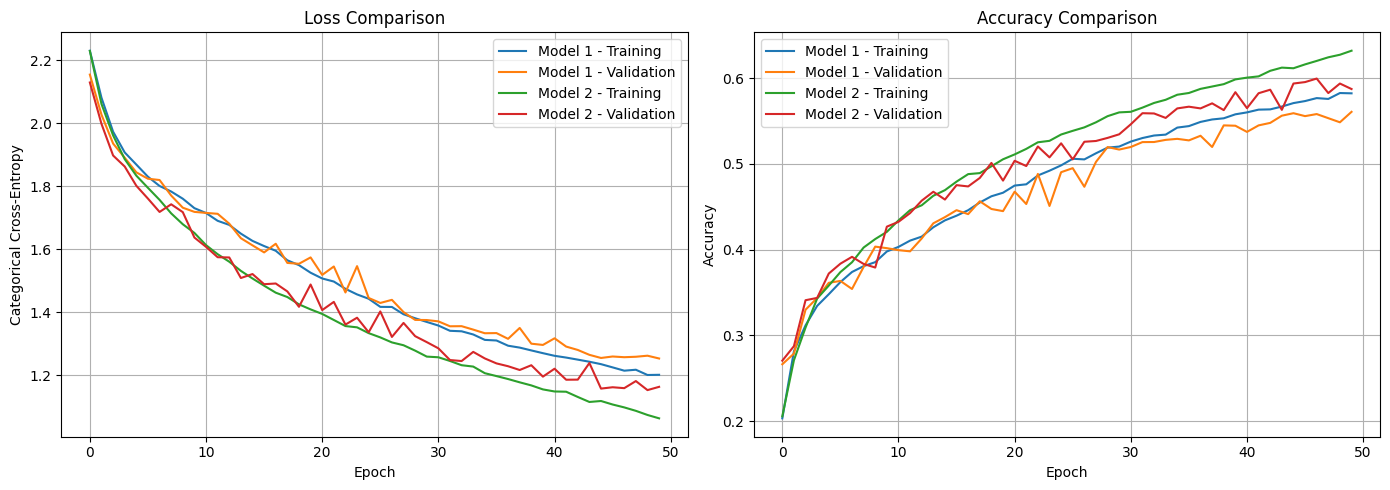

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['loss'], label='Model 1 - Training')
axes[0].plot(history1.history['val_loss'], label='Model 1 - Validation')
axes[0].plot(history2.history['loss'], label='Model 2 - Training')
axes[0].plot(history2.history['val_loss'], label='Model 2 - Validation')
axes[0].set_title('Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Cross-Entropy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history1.history['accuracy'], label='Model 1 - Training')
axes[1].plot(history1.history['val_accuracy'], label='Model 1 - Validation')
axes[1].plot(history2.history['accuracy'], label='Model 2 - Training')
axes[1].plot(history2.history['val_accuracy'], label='Model 2 - Validation')
axes[1].set_title('Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

The deeper VGG-style model is expected to perform better because stacking convolutional layers allows the network to learn more complex hierarchical features. The first convolutional layers can learn simple patterns such as edges and textures, while deeper layers combine them into more meaningful shapes.

The validation curves should be used to make the final judgment. If Model 2 has higher validation accuracy and lower validation loss, it generalizes better. If its training accuracy continues increasing while validation accuracy stops improving or decreases, the model is beginning to overfit.

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


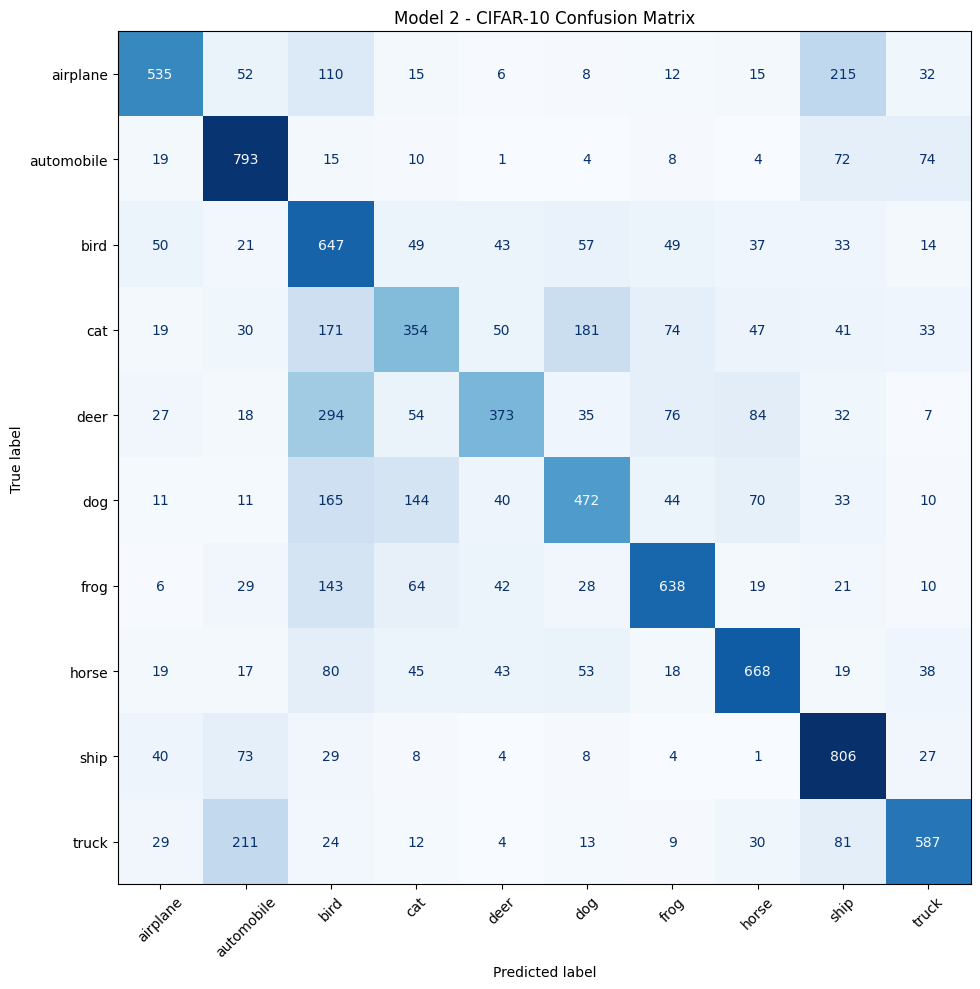

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict class probabilities and convert them to class indices
y_pred_prob = model2.predict(x_test, batch_size=512, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d', colorbar=False)
ax.set_title('Model 2 - CIFAR-10 Confusion Matrix')
plt.tight_layout()
plt.show()

The confusion matrix shows which CIFAR-10 classes are most frequently confused. Similar-looking classes tend to have more errors; for example, cats and dogs can be confused because their visual features are similar. Likewise, automobile and truck can be confused because both are road vehicles. The diagonal contains correct predictions, so a stronger diagonal indicates better classification performance.

*    Print the test accuracy for the trained model.

In [12]:
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test, batch_size=512, verbose=1)
print(f'Test loss: {test_loss2:.4f}')
print(f'Test accuracy: {test_accuracy2:.4%}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5873 - loss: 1.1627
Test loss: 1.1627
Test accuracy: 58.7300%


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [13]:
from keras.backend import clear_session
clear_session()

In [14]:
from tensorflow.keras.layers import Input

# Complete VGG-style architecture for 64 x 64 input
model3 = Sequential([
    Input(shape=(64, 64, 3)),

    # Block 1: 64 filters
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: 128 filters
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: 256 filters
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.1124 - loss: 2.3004 - val_accuracy: 0.1142 - val_loss: 2.2979
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 54s 547ms/step - accuracy: 0.1324 - loss: 2.2938 - val_accuracy: 0.1399 - val_loss: 2.2874
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 82s 552ms/step - accuracy: 0.1519 - loss: 2.2707 - val_accuracy: 0.1811 - val_loss: 2.2373
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 52s 535ms/step - accuracy: 0.2235 - loss: 2.1641 - val_accuracy: 0.1817 - val_loss: 2.2176
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 53s 545ms/step - accuracy: 0.2613 - loss: 2.0491 - val_accuracy: 0.2673 - val_loss: 2.0331
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 54s 547ms/step - accuracy: 0.2920 - loss: 1.9787 - val_accuracy: 0.2657 - val_loss: 2.0210
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 53s 543ms/step - accuracy: 0.3120 - loss: 1.9405 - val_accuracy: 0.3341 - val_loss: 1.8614
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 53s 543ms/step - accuracy: 0.3328 - loss: 1.8813 - val_accura

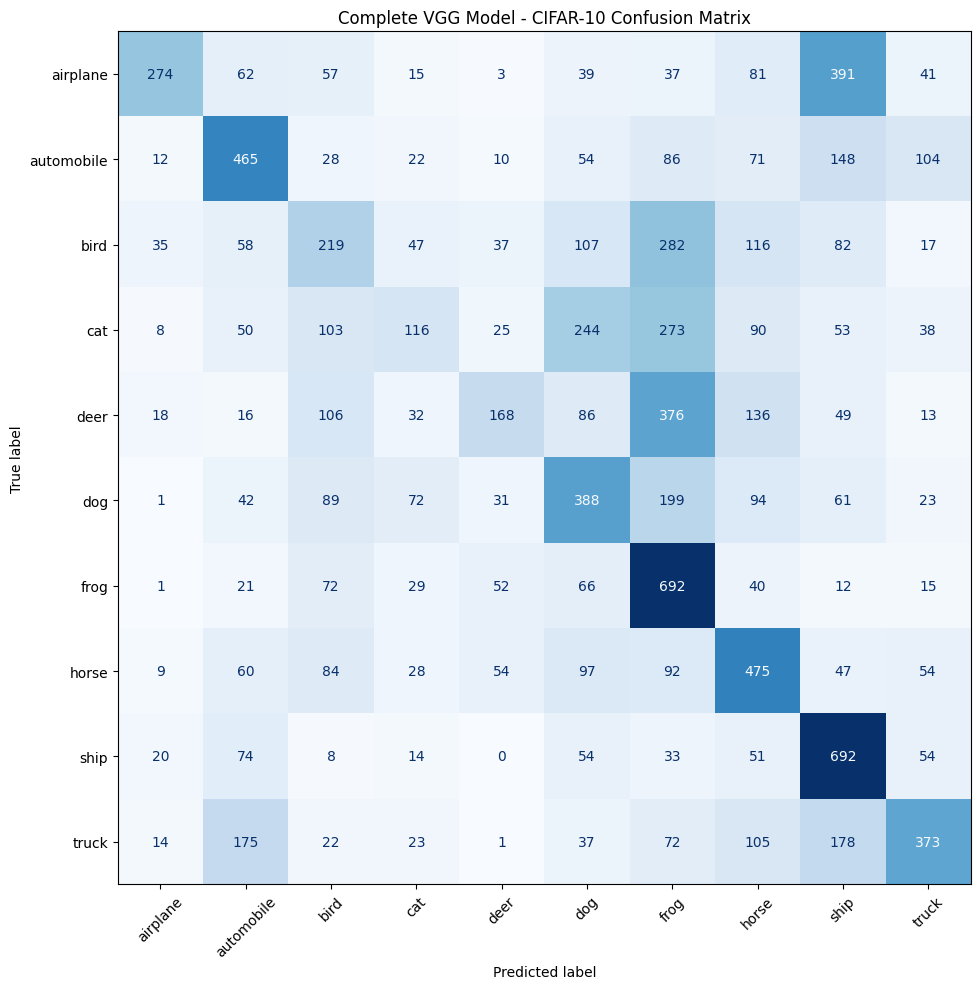

Most common class confusions can be identified by inspecting the largest off-diagonal values in the matrix.


In [15]:
model3.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

# Resize 32x32 CIFAR-10 images to 64x64 without creating a large 64x64
# copy of the entire training set in memory.
import tensorflow as tf

def resize_images(images, labels):
    images = tf.image.resize(images, (64, 64))
    return images, labels

train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .shuffle(10000, seed=42)
            .map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(512)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
           .map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(512)
           .prefetch(tf.data.AUTOTUNE))

history3 = model3.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    verbose=1
)

# Predict on the resized test set
y_pred_prob3 = model3.predict(test_ds, verbose=1)
y_pred3 = np.argmax(y_pred_prob3, axis=1)
y_true3 = np.argmax(y_test, axis=1)

cm3 = confusion_matrix(y_true3, y_pred3)
fig, ax = plt.subplots(figsize=(10, 10))
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=class_names)
disp3.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d', colorbar=False)
ax.set_title('Complete VGG Model - CIFAR-10 Confusion Matrix')
plt.tight_layout()
plt.show()

print('Most common class confusions can be identified by inspecting the largest off-diagonal values in the matrix.')

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

1 - Use of activation functions:

Activation functions introduce non-linearity into a neural network. Without activation functions, stacking multiple layers would still result in a linear transformation, so the network could not learn complex non-linear relationships. They therefore allow deep networks to learn complex patterns and decision boundaries. ReLU is commonly used in hidden layers because it is simple and helps reduce the vanishing-gradient problem compared with sigmoid/tanh in many deep networks.


2 - Key Differences between sigmoid and softmax:

Sigmoid maps one value to a number between 0 and 1 and is commonly used for binary classification or independent multi-label outputs. Each output can be interpreted independently. Softmax converts a vector of logits into a probability distribution whose values sum to 1. It is therefore commonly used for mutually exclusive multi-class classification, such as the 10 CIFAR-10 classes.


3 - Key Differences between categorical crossentropy and binary crossentropy loss:

Categorical crossentropy is generally used for multi-class classification when each sample belongs to exactly one class and the target is represented as a one-hot vector (as in this CIFAR-10 exercise). Binary crossentropy is used for binary classification, or for multi-label classification where each class is an independent yes/no decision. In this exercise, categorical crossentropy is appropriate because there are 10 mutually exclusive classes and the labels are one-hot encoded.